In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.interpolate import interp1d

Text(0, 0.5, 'Precipitation [in/h]')

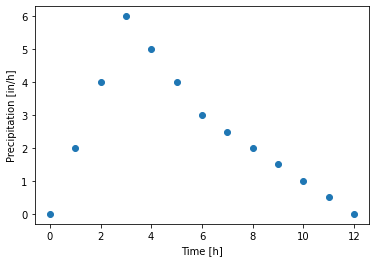

In [6]:
# Make synthetic data
time_h = [0,1,2,3,4,5,6,7,8,9,10,11,12]
ppt_inph = [0,2,4,6,5,4,3,2.5,2,1.5,1,0.5,0]
plt.scatter(time_h,ppt_inph)
plt.xlabel('Time [h]')
plt.ylabel('Precipitation [in/h]')

Text(0, 0.5, 'Precipitation [in/h]')

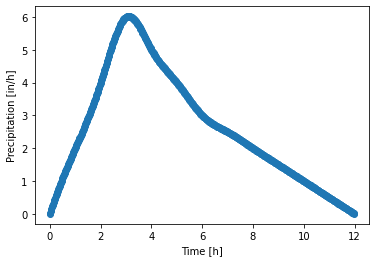

In [11]:
# Interpolate data for generation of more synthetic data
f = interp1d(time_h, ppt_inph, kind='cubic')
time_h_dense = np.arange(0, 12, 1/60)
ppt_inph_dense = f(time_h_dense)
plt.scatter(time_h_dense,ppt_inph_dense)
plt.xlabel('Time [h]')
plt.ylabel('Precipitation [in/h]')

Text(0, 0.5, 'Precipitation [in/min]')

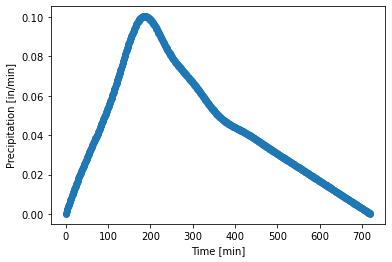

In [12]:
# Correct units from h to min
time_min = time_h_dense*60
ppt_inpm = ppt_inph_dense/60
plt.scatter(time_min,ppt_inpm)
plt.xlabel('Time [min]')
plt.ylabel('Precipitation [in/min]')

Text(0, 0.5, 'Precipitation [in]')

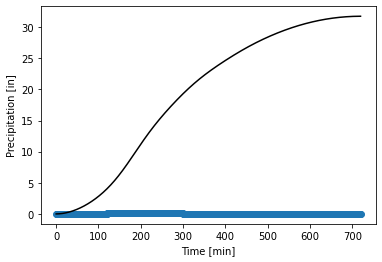

In [14]:
# plot accumulative rainfall
acc_rainfall = []
acc = 0
for i in ppt_inpm:
    acc += i
    acc_rainfall.append(acc)
plt.scatter(time_min,ppt_inpm)
plt.plot(time_min,acc_rainfall,'k-')
plt.xlabel('Time [min]')
plt.ylabel('Precipitation [in]')

Text(0, 0.5, 'Precipitation [cfs]')

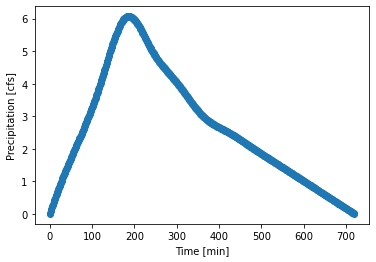

In [15]:
# plot precipitation in cfs vs time in minute
# assume a watershed with a area of 1 acre (43560 ft2)
ppt_cfs = ppt_inpm/12*43560/60
plt.scatter(time_min,ppt_cfs)
plt.xlabel('Time [min]')
plt.ylabel('Precipitation [cfs]')

Text(0, 0.5, 'Precipitation [cfs]')

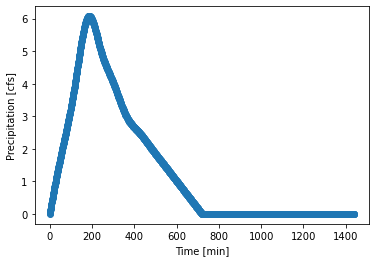

In [45]:
# Padding with more zero data to make a full day time frame
for i in range(720,1441):
    time_min = np.append(time_min,i)
    ppt_cfs = np.append(ppt_cfs,0)
plt.scatter(time_min,ppt_cfs)
plt.xlabel('Time [min]')
plt.ylabel('Precipitation [cfs]')

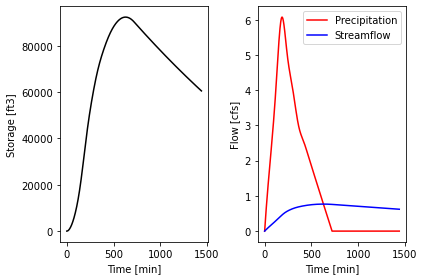

In [50]:
# if there is no abstraction, all rainfall will become runoff. The above figure will be a runoff figure as well. 
# define a storage reservoir with a trial volume of 10,000 ft3 and a base area of 1,000 ft2. The reservoir has a bottom discharge pipe with a diameter of 1 ft. 
# compute the water level in the storage reservoir
S_max = 100000 # maximum storage volume of the reservoir in ft3
Ab = 10000 # base area of the reservoir in ft2
Ap = 0.2 # discharge pipe diameter of the reservoir in ft. If this is changed to zero, it will be a overflow reservoir only. 

S_li = [] # storage list
flow_li = [] # list of runoff flow rate in cfs
S = 0 # inital storage
for ppt in ppt_cfs:
    inf = ppt
    S += inf*60
    if (S > 0) & (S <= S_max):
        eff = np.sqrt(2*32.2*S/Ab)*(np.pi*Ap**2)/4
        overflow = 0
    elif S <=0:
        eff = 0
        overflow = 0
    elif S > S_max:
        eff = np.sqrt(2*32.2*S_max/Ab)*(np.pi*Ap**2)/4
        overflow = (S-S_max)/60
        S = S_max
    S -= eff*60
    if S < 0:
        S = 0
    S_li.append(S)
    flow = eff + overflow
    flow_li.append(flow)

plt.subplot(121)
plt.plot(time_min,S_li,'k-')
plt.xlabel('Time [min]')
plt.ylabel('Storage [ft3]')

plt.subplot(122)
plt.plot(time_min,ppt_cfs,'r-',label='Precipitation')
plt.plot(time_min,flow_li,'b-',label='Streamflow')
plt.xlabel('Time [min]')
plt.ylabel('Flow [cfs]')
plt.legend()
plt.tight_layout()
